# Cluster sequence analysis: structural patterns in page sequences

Once pages (or scans) are assigned to clusters -- whether via DINOv2 visual embeddings or
text-line layout clustering -- the *sequence* of cluster labels carries structural information
about the archive.  Long homogeneous runs, recurring n-grams, and tandem repeats of cluster
sub-sequences can reveal section boundaries, repeating document units, and the overall rhythm
of the inventory.

This notebook demonstrates two complementary approaches for two inventories:

* **`NL-HaNA_2.10.50_1`** (table register): both visual clustering (DINOv2 embeddings, scan
  level, pre-computed cache) and layout clustering (text-line geometry, page level after
  splitting).  The two approaches both reveal the alternation between long table sections and
  title-page section separators.

* **`NL-AsnDA_0114.11_1`** (notary deeds): both layout clustering and visual clustering
  (DINOv2, page level, computed here from scan thumbnail crops).  Empty pages — the blank
  recto halves of the notarial blank-recto convention — are **kept in the sequence** as a
  structural signal, not removed.  The layout analysis uses them as a distinct label (-2);
  DINOv2 discovers them as a separate cluster by visual appearance alone.

All sequence analysis functions come from
`archival_structures.stream_analysis.sequence_analysis`.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import umap
import hdbscan
import pagexml.parser as pagexml_parser

from archival_structures.analysis.opening_detection import (
    classify_inventory_structure, split_inventory_into_pages,
    compute_corpus_median_width, is_opening, get_opening_features, split_scan,
)
from archival_structures.analysis.page_layout_clustering import cluster_page_layouts
from archival_structures.stream_analysis import (
    run_length_encode, merge_short_runs,
    ngram_counts, find_frequent_ngrams,
    find_tandem_repeats, label_transition_matrix,
)

REPO_ROOT = Path('../../')
DATA_ROOT = REPO_ROOT / 'data'

## Shared visualisation utilities

A horizontal sequence strip shows cluster labels as colour-coded blocks.
Each block corresponds to one scan or page; block width is uniform (not proportional to
run length -- see the run-length encoded view below for that).

In [2]:
CLUSTER_COLORS = [
    '#4e79a7', '#f28e2b', '#e15759', '#76b7b2',
    '#59a14f', '#edc948', '#b07aa1', '#ff9da7',
    '#9c755f', '#bab0ac',
]
NOISE_COLOR = '#cccccc'

def cluster_color(label, noise_label=-1):
    if label == noise_label:
        return NOISE_COLOR
    return CLUSTER_COLORS[label % len(CLUSTER_COLORS)]


def plot_label_sequence(
    labels,
    title='',
    ax=None,
    noise_label=-1,
    cluster_names=None,
    height=0.6,
):
    """Horizontal strip: each position = one label, colour = cluster."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 1.2))
    labels = list(labels)
    for i, lab in enumerate(labels):
        ax.add_patch(plt.Rectangle(
            (i, 0), 1, height,
            color=cluster_color(lab, noise_label), linewidth=0,
        ))
    ax.set_xlim(0, len(labels))
    ax.set_ylim(0, height)
    ax.set_yticks([])
    ax.set_xlabel('Position')
    if title:
        ax.set_title(title)
    # Legend
    unique = sorted(set(labels))
    patches = []
    for u in unique:
        name = cluster_names.get(u, f'cluster {u}') if cluster_names else (
            'noise' if u == noise_label else f'cluster {u}'
        )
        patches.append(mpatches.Patch(color=cluster_color(u, noise_label), label=name))
    ax.legend(handles=patches, loc='upper right', fontsize=8, framealpha=0.8)
    return ax


def plot_rle_sequence(
    rle,
    title='',
    ax=None,
    noise_label=-1,
    cluster_names=None,
    height=0.6,
):
    """Run-length encoded strip: block WIDTH is proportional to run length."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 1.2))
    total = sum(r['length'] for r in rle)
    x = 0
    for r in rle:
        ax.add_patch(plt.Rectangle(
            (x, 0), r['length'], height,
            color=cluster_color(r['cluster'], noise_label), linewidth=0,
        ))
        x += r['length']
    ax.set_xlim(0, total)
    ax.set_ylim(0, height)
    ax.set_yticks([])
    ax.set_xlabel('Position')
    if title:
        ax.set_title(title)
    unique = sorted(set(r['cluster'] for r in rle))
    patches = []
    for u in unique:
        name = cluster_names.get(u, f'cluster {u}') if cluster_names else (
            'noise' if u == noise_label else f'cluster {u}'
        )
        patches.append(mpatches.Patch(color=cluster_color(u, noise_label), label=name))
    ax.legend(handles=patches, loc='upper right', fontsize=8, framealpha=0.8)
    return ax

---
## Part 1: Visual clustering — `NL-HaNA_2.10.50_1`

`NL-HaNA_2.10.50_1` is a table register: most of its 336 scans are dense two-column tables,
interrupted by occasional single-page title scans that mark the start of a new section.

DINOv2 embeddings have been pre-computed and cached (via `run_overview`).
We cluster them directly in embedding space (UMAP + HDBSCAN) and examine the cluster sequence.

In [3]:
EMBS_DIR = DATA_ROOT / 'stream_analysis/NL-HaNA/NL-HaNA_2.10.50/1'

emb_2105 = np.load(EMBS_DIR / 'embeddings.npy')
with open(EMBS_DIR / 'image_ids.json') as f:
    image_ids_2105 = json.load(f)

print(f'Embeddings: {emb_2105.shape}   ({len(image_ids_2105)} scans)')

Embeddings: (336, 768)   (336 scans)


In [4]:
# UMAP: reduce to 10 dimensions before HDBSCAN
reducer_2105 = umap.UMAP(n_components=10, n_neighbors=15, metric='cosine', random_state=42)
umap_2105 = reducer_2105.fit_transform(emb_2105)

clusterer_2105 = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=2)
clusterer_2105.fit(umap_2105)
vis_labels_2105 = clusterer_2105.labels_.tolist()

from collections import Counter
print('Visual cluster distribution:', sorted(Counter(vis_labels_2105).items()))

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Visual cluster distribution: [(0, 320), (1, 5), (2, 11)]


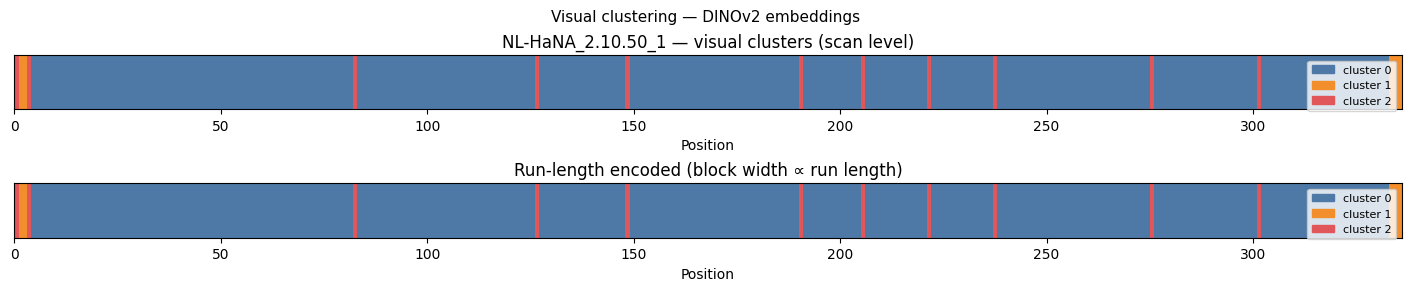


23 runs  (range 1–78 pages)


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 2.8), constrained_layout=True)
plot_label_sequence(vis_labels_2105, title='NL-HaNA_2.10.50_1 — visual clusters (scan level)', ax=axes[0])
rle_vis = run_length_encode(vis_labels_2105)
plot_rle_sequence(rle_vis, title='Run-length encoded (block width ∝ run length)', ax=axes[1])
plt.suptitle('Visual clustering — DINOv2 embeddings', fontsize=11)
plt.show()

print(f'\n{len(rle_vis)} runs  (range {min(r["length"] for r in rle_vis)}–{max(r["length"] for r in rle_vis)} pages)')

In [6]:
# Tandem repeats: the title-page scans (cluster 2) form a regular punctuation pattern
tr_vis = find_tandem_repeats(vis_labels_2105, min_unit=1, max_unit=4, min_repeats=2)
print(f'{len(tr_vis)} tandem repeats:')
print(tr_vis.to_string(index=False))

42 tandem repeats:
        unit  unit_length  start  n_repeats  end  total_length
        (1,)            1      1          2    3             2
   (0, 0, 0)            3      4         26   82            78
      (0, 0)            2      4         39   82            78
(0, 0, 0, 0)            4      4         19   80            76
        (0,)            1      4         78   82            78
   (0, 0, 0)            3     83         14  125            42
        (0,)            1     83         43  126            43
      (0, 0)            2     83         21  125            42
(0, 0, 0, 0)            4     83         10  123            40
(0, 0, 0, 0)            4    127          5  147            20
   (0, 0, 0)            3    127          7  148            21
      (0, 0)            2    127         10  147            20
        (0,)            1    127         21  148            21
        (0,)            1    149         41  190            41
   (0, 0, 0)            3    149    

In [7]:
# Transition matrix: what cluster follows what?
tm_vis = label_transition_matrix(vis_labels_2105, normalize=True)
print('Transition probabilities (row=from, col=to):')
print(tm_vis.round(2).to_string())

Transition probabilities (row=from, col=to):
      0     1     2
0  0.97  0.00  0.03
1  0.00  0.75  0.25
2  0.91  0.09  0.00


In [8]:
# Identify the title-page scans (cluster 2 = single-scan punctuation marks)
title_positions = [i for i, c in enumerate(vis_labels_2105) if c == 2]
title_gaps = [title_positions[i+1] - title_positions[i] for i in range(len(title_positions)-1)]
print(f'Cluster-2 (title) scan positions ({len(title_positions)} total): {title_positions}')
print(f'Gaps between title scans: {title_gaps}')
print(f'  → section lengths (scans of tables between titles): min={min(title_gaps)}, max={max(title_gaps)}, mean={np.mean(title_gaps):.1f}')

Cluster-2 (title) scan positions (11 total): [0, 3, 82, 126, 148, 190, 205, 221, 237, 275, 301]
Gaps between title scans: [3, 79, 44, 22, 42, 15, 16, 16, 38, 26]
  → section lengths (scans of tables between titles): min=3, max=79, mean=30.1


## Part 2: Layout clustering — `NL-HaNA_2.10.50_1`

For comparison, we now cluster the same inventory by text-line layout (grid-pattern TF-IDF)
after splitting the two-page scans into individual pages.  This is a different signal --
the visual approach sees the full scan image; the layout approach sees the geometry of
the transcribed text lines.

The table register has a very uniform dense-table layout, so many pages end up as noise (-1)
in the layout clustering.  `merge_short_runs` absorbs isolated noise pages into their larger
neighbours to recover a cleaner pattern.

In [9]:
PXD_2105 = DATA_ROOT / 'PageXML/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_1'
xml_files = sorted(PXD_2105.glob('*.xml'))
scans_2105 = [pagexml_parser.parse_pagexml_file(str(p)) for p in xml_files]

structure_2105 = classify_inventory_structure(scans_2105)
print(f'Structure: {structure_2105.structure_type}  ({structure_2105.type_counts})')
pages_2105 = split_inventory_into_pages(scans_2105, structure=structure_2105)
print(f'{len(scans_2105)} scans → {len(pages_2105)} pages')

Structure: book_of_openings  ({'opening': 242, 'single_page': 88, 'odd_shaped': 6})


336 scans → 578 pages


In [10]:
lay_labels_2105, lay_clusterer_2105 = cluster_page_layouts(
    pages_2105, min_cluster_size=10, min_samples=3,
)
lay_labels_2105 = lay_labels_2105.tolist()
print('Layout cluster distribution:', sorted(Counter(lay_labels_2105).items()))
print(f'Noise fraction: {lay_labels_2105.count(-1)/len(lay_labels_2105):.1%}')

done setting base grid points
took 0.0 seconds (total: 0.0)


done setting line grid_points for 578 docs, with 200 x and 189 y points
took 0.3 seconds (total: 0.3)


done computing patterns, 438 distinct patterns
took 24.7 seconds (total: 25.1)
done computing tf-idf of patterns
took 0.1 seconds (total: 25.2)


Layout cluster distribution: [(-1, 463), (0, 29), (1, 10), (2, 11), (3, 11), (4, 18), (5, 22), (6, 14)]
Noise fraction: 80.1%


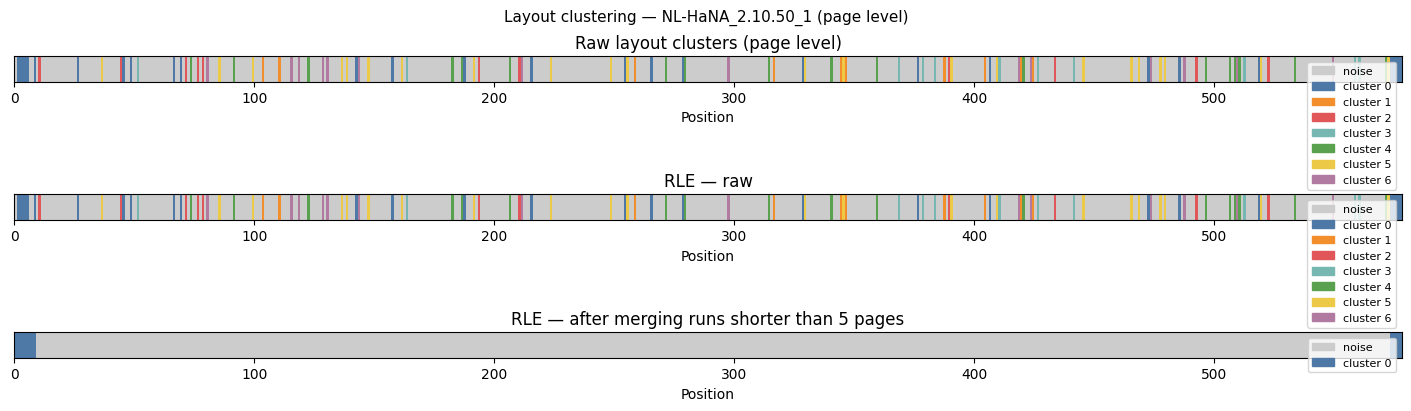

In [11]:
# Raw layout sequence
fig, axes = plt.subplots(3, 1, figsize=(14, 4.0), constrained_layout=True)
plot_label_sequence(lay_labels_2105, title='Raw layout clusters (page level)', ax=axes[0])
rle_lay = run_length_encode(lay_labels_2105)
plot_rle_sequence(rle_lay, title='RLE — raw', ax=axes[1])

# After merging short noise runs
rle_lay_merged = merge_short_runs(rle_lay, min_length=5)
lay_labels_merged = []
for r in rle_lay_merged:
    lay_labels_merged.extend([r['cluster']] * r['length'])
plot_rle_sequence(rle_lay_merged, title='RLE — after merging runs shorter than 5 pages', ax=axes[2])
plt.suptitle('Layout clustering — NL-HaNA_2.10.50_1 (page level)', fontsize=11)
plt.show()

---
## Part 3: Layout clustering — `NL-AsnDA_0114.11_1`

The notary deeds inventory has a very different structure: each deed occupies a
fixed number of pages following a predictable layout: one or more full-text pages,
occasionally a table-like summary, then a short closing page (large empty margin at the
bottom, above a few signature lines).

The `classify_inventory_structure` heuristic does not recognise this archive as a book
of openings (the single-page width in the front matter and the opening width are not
in a clean 1:2 ratio).  We fall back to the gap heuristic: scan by scan, check `is_opening`
and split if so.

**Empty pages are kept in the sequence** as a distinct label (`EMPTY_LABEL = -2`).  In
notary deed archives, blank recto halves are not gaps in the data — they mark deed boundaries
and are structurally significant.  Pattern functions such as `find_frequent_ngrams` and
`find_tandem_repeats` use `noise_label=-1` (the HDBSCAN noise label), so `-2` appears as
a regular cluster in the analysis.

In [12]:
PXD_ASDA = DATA_ROOT / 'PageXML/NL-AsnDA/NL-AsnDA_0114.11/NL-AsnDA_0114.11_1'
xml_files_asda = sorted(PXD_ASDA.glob('*.xml'))
scans_asda = [pagexml_parser.parse_pagexml_file(str(p)) for p in xml_files_asda]
print(f'{len(scans_asda)} scans')

# Split with gap heuristic (is_opening + split_scan)
median_w = compute_corpus_median_width(scans_asda)
pages_asda = []
for scan in scans_asda:
    if is_opening(scan, corpus_median_width=median_w):
        feat = get_opening_features(scan, corpus_median_width=median_w)
        verso, recto = split_scan(scan, feat.separation_point)
        pages_asda += [verso, recto]
    else:
        pages_asda.append(scan)

from archival_structures.analysis.boundary_detection import is_empty_page
n_empty = sum(1 for p in pages_asda if is_empty_page(p))
print(f'{len(scans_asda)} scans → {len(pages_asda)} pages  ({n_empty} empty, {n_empty/len(pages_asda):.0%})')

630 scans


630 scans → 1258 pages  (289 empty, 23%)


In [13]:
# Cluster only non-empty pages; re-join into full sequence
pages_with_text_asda = [p for p in pages_asda if not is_empty_page(p)]
lay_labels_asda_text, lay_clusterer_asda = cluster_page_layouts(
    pages_with_text_asda, min_cluster_size=5, min_samples=2,
)
text_labels_by_id = {
    p.id: int(lay_labels_asda_text.iloc[i])
    for i, p in enumerate(pages_with_text_asda)
}

# Full sequence with -2 for empty pages, cluster label or -1 for text pages
EMPTY_LABEL = -2
lay_labels_asda = [
    EMPTY_LABEL if is_empty_page(p) else text_labels_by_id.get(p.id, -1)
    for p in pages_asda
]

print('Layout cluster distribution (excluding empty pages):')
print(sorted(Counter(lay_labels_asda_text.tolist()).items()))
print(f'Noise fraction (non-empty pages): {lay_labels_asda_text.tolist().count(-1)/len(pages_with_text_asda):.1%}')

done setting base grid points
took 0.0 seconds (total: 0.0)
done setting line grid_points for 969 docs, with 54 x and 81 y points
took 0.1 seconds (total: 0.1)


done computing patterns, 482 distinct patterns
took 4.5 seconds (total: 4.7)
done computing tf-idf of patterns
took 0.1 seconds (total: 4.8)


Layout cluster distribution (excluding empty pages):
[(-1, 528), (0, 5), (1, 41), (2, 8), (3, 379), (4, 8)]
Noise fraction (non-empty pages): 54.5%


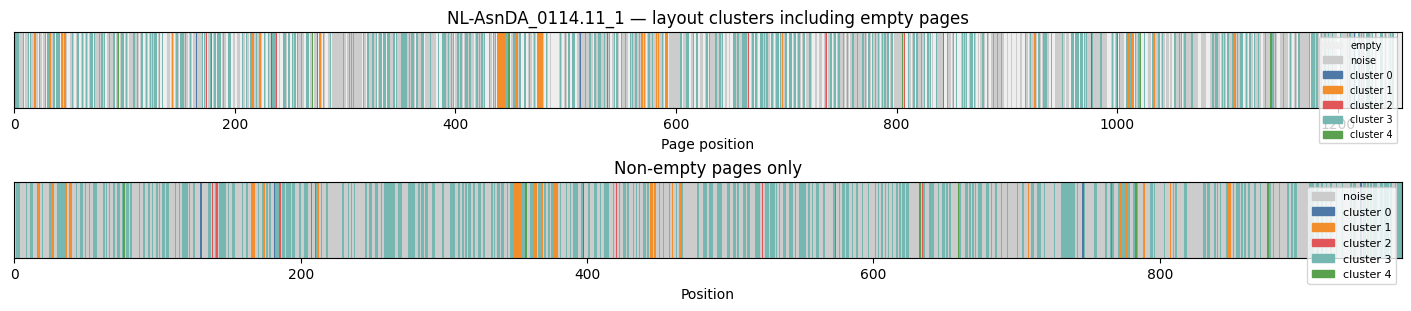

In [14]:
# Visualise (empty pages shown as a dedicated color)
EMPTY_COLOR = '#eeeeee'

def cluster_color_asda(label):
    if label == EMPTY_LABEL:
        return EMPTY_COLOR
    return cluster_color(label)

fig, axes = plt.subplots(2, 1, figsize=(14, 3.0), constrained_layout=True)

labels_nonempty_only = [l for l in lay_labels_asda if l != EMPTY_LABEL]

# Full sequence including empty pages
ax = axes[0]
height = 0.6
for i, lab in enumerate(lay_labels_asda):
    ax.add_patch(plt.Rectangle((i, 0), 1, height, color=cluster_color_asda(lab), linewidth=0))
ax.set_xlim(0, len(lay_labels_asda))
ax.set_ylim(0, height)
ax.set_yticks([])
ax.set_xlabel('Page position')
ax.set_title('NL-AsnDA_0114.11_1 — layout clusters including empty pages')
unique_labels = sorted(set(lay_labels_asda))
label_names = {EMPTY_LABEL: 'empty', -1: 'noise'}
patches = [mpatches.Patch(
    color=cluster_color_asda(u),
    label=label_names.get(u, f'cluster {u}')
) for u in unique_labels]
ax.legend(handles=patches, loc='upper right', fontsize=7, framealpha=0.8)

# Non-empty pages only
plot_label_sequence(
    labels_nonempty_only,
    title='Non-empty pages only',
    ax=axes[1],
)
plt.show()

In [15]:
# Analyse the FULL page sequence, keeping empty pages (EMPTY_LABEL = -2) as a real cluster.
# Noise (-1) is not merged; pattern functions skip it via noise_label=-1 (their default).
# This reveals the deed rhythm directly: (full-text, empty) alternations signal each deed unit.
rle_asda = run_length_encode(lay_labels_asda, noise_label=-1)
merged_labels_asda = lay_labels_asda   # no merging; noise skipped by find_* functions

print('Full sequence distribution:')
non_noise = [l for l in merged_labels_asda if l != -1]
print(sorted(Counter(non_noise).items()))
print(f'\nEmpty pages (-2): {merged_labels_asda.count(EMPTY_LABEL)} '
      f'({merged_labels_asda.count(EMPTY_LABEL)/len(merged_labels_asda):.1%})')
print(f'Noise pages (-1): {merged_labels_asda.count(-1)} '
      f'({merged_labels_asda.count(-1)/len(merged_labels_asda):.1%})')

Full sequence distribution:
[(-2, 289), (0, 5), (1, 41), (2, 8), (3, 379), (4, 8)]

Empty pages (-2): 289 (23.0%)
Noise pages (-1): 528 (42.0%)


In [16]:
# Frequent n-grams: noise (-1) is skipped; empty (-2) appears as a real cluster.
# Expect (cluster 3, -2) to dominate — full-text deed page followed by blank recto.
ngrams_asda = find_frequent_ngrams(merged_labels_asda, n=(2, 3, 4), min_count=5, noise_label=-1)
print('Most frequent n-grams in AsnDA (empty pages included, noise skipped):')
print(ngrams_asda[['ngram', 'n', 'count']].head(20).to_string(index=False))

Most frequent n-grams in AsnDA (empty pages included, noise skipped):
          ngram  n  count
         (3, 3)  2    115
       (-2, -2)  2     98
        (-2, 3)  2     86
        (3, -2)  2     74
     (3, 3, -2)  3     40
    (-2, -2, 3)  3     32
      (3, 3, 3)  3     29
     (-2, 3, 3)  3     29
   (-2, -2, -2)  3     28
    (3, -2, -2)  3     24
     (3, -2, 3)  3     24
         (1, 1)  2     17
  (3, 3, -2, 3)  4     16
  (-2, 3, 3, 3)  4     15
         (3, 1)  2     14
  (3, 3, 3, -2)  4     11
     (-2, 3, 1)  3     10
(3, -2, -2, -2)  4      9
 (-2, -2, 3, 3)  4      9
(-2, -2, -2, 3)  4      9


In [17]:
# Tandem repeats (noise skipped, empty treated as real cluster).
# The pair (cluster 3, -2) repeated many times encodes the deed unit: text page + blank recto.
tr_asda = find_tandem_repeats(
    merged_labels_asda, min_unit=1, max_unit=4, min_repeats=3, noise_label=-1,
)
print(f'{len(tr_asda)} tandem repeats  (≥ 3 consecutive repetitions):')
if len(tr_asda) > 0:
    print(tr_asda[['unit', 'unit_length', 'start', 'n_repeats', 'total_length']]
          .head(20).to_string(index=False))

55 tandem repeats  (≥ 3 consecutive repetitions):
  unit  unit_length  start  n_repeats  total_length
  (3,)            1      1          3             3
  (3,)            1     38          3             3
 (-2,)            1    135          3             3
  (3,)            1    150          4             4
  (3,)            1    184          3             3
  (3,)            1    234          3             3
 (-2,)            1    241          3             3
  (3,)            1    264          3             3
  (3,)            1    334          3             3
  (3,)            1    338          3             3
  (3,)            1    351          5             5
 (-2,)            1    385          3             3
  (3,)            1    388          3             3
 (-2,)            1    427          3             3
  (1,)            1    439          6             6
(1, 1)            2    439          3             6
  (3,)            1    445          3             3
  (3,)        

In [18]:
# Transition matrix — empty pages (-2) included as a real cluster; noise (-1) excluded.
# High self-loop of -2→-2 would be unusual (blank rectos alternate with text pages).
# High probability of 3→-2 and -2→3 confirms the regular alternating deed structure.
tm_asda = label_transition_matrix(merged_labels_asda, normalize=True, noise_label=-1)
print('Transition probabilities — AsnDA layout (empty pages included, noise excluded):')
print(tm_asda.round(2).to_string())

Transition probabilities — AsnDA layout (empty pages included, noise excluded):
      -2     0     1     2     3     4
-2  0.41  0.00  0.00  0.00  0.57  0.01
 0  0.20  0.00  0.00  0.00  0.80  0.00
 1  0.22  0.00  0.49  0.00  0.29  0.00
 2  0.88  0.00  0.00  0.00  0.12  0.00
 3  0.39  0.01  0.05  0.02  0.52  0.01
 4  0.75  0.00  0.00  0.12  0.12  0.00


---
## Part 4: Visual clustering — `NL-AsnDA_0114.11_1`

We now apply DINOv2 visual clustering to the notary deeds inventory, embedding each page half
(verso / recto crop of each two-page scan thumbnail) with the `facebook/dinov2-base` model.
Empty verso/recto halves will form their own visual cluster — the blank-recto convention that
layout analysis confirmed in Part 3 should emerge from appearance alone, independently
validating the layout finding with a completely independent signal.

In [19]:
import torch
from transformers import AutoImageProcessor, AutoModel
from PIL import Image

_dino_device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
_dino_processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
_dino_model = AutoModel.from_pretrained('facebook/dinov2-base').to(_dino_device).eval()
print(f'DINOv2 loaded on {_dino_device}')


def _embed_page_halves(scans, thumb_dir, thumb_fn, device, processor, model,
                        corpus_median_width, cache_path=None, batch_size=32):
    page_images, page_keys = [], []
    for scan in scans:
        p = thumb_dir / thumb_fn(scan)
        if not p.exists():
            continue
        img = Image.open(p).convert('RGB')
        if scan.coords.w >= 0.85 * corpus_median_width:
            mid = img.width // 2
            page_images.append(img.crop((0, 0, mid, img.height)))
            page_keys.append((scan.id, 'verso'))
            page_images.append(img.crop((mid, 0, img.width, img.height)))
            page_keys.append((scan.id, 'recto'))
        else:
            page_images.append(img)
            page_keys.append((scan.id, 'full'))

    if cache_path is not None and Path(cache_path).exists():
        print(f'  loaded from cache: {cache_path}')
        return np.load(cache_path), page_keys

    all_cls = []
    for i in range(0, len(page_images), batch_size):
        batch = page_images[i:i+batch_size]
        inputs = processor(images=batch, return_tensors='pt').to(device)
        with torch.no_grad():
            out = model(**inputs)
        all_cls.append(out.last_hidden_state[:, 0].cpu().numpy())
    emb = np.vstack(all_cls)
    emb = emb / np.linalg.norm(emb, axis=1, keepdims=True)

    if cache_path is not None:
        Path(cache_path).parent.mkdir(parents=True, exist_ok=True)
        np.save(cache_path, emb)
        print(f'  cached to {cache_path}')
    return emb, page_keys


THUMB_DIR_ASDA = DATA_ROOT / 'thumbs/NL-AsnDA/NL-AsnDA_0114.11/NL-AsnDA_0114.11_1'
EMB_CACHE_ASDA = DATA_ROOT / 'stream_analysis/NL-AsnDA/NL-AsnDA_0114.11/1/page_embeddings.npy'

emb_asda_vis, page_keys_asda = _embed_page_halves(
    scans_asda, THUMB_DIR_ASDA,
    lambda scan: f'thumb-width_300-scan-{scan.id.replace(".jpg", ".jp2")}.png',
    _dino_device, _dino_processor, _dino_model,
    corpus_median_width=median_w,
    cache_path=EMB_CACHE_ASDA,
)
print(f'AsnDA page embeddings: {emb_asda_vis.shape}  ({len(page_keys_asda)} pages)')

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 loaded on mps


  loaded from cache: ../../data/stream_analysis/NL-AsnDA/NL-AsnDA_0114.11/1/page_embeddings.npy
AsnDA page embeddings: (1258, 768)  (1258 pages)


In [20]:
reducer_asda_vis = umap.UMAP(n_components=10, n_neighbors=15, metric='cosine', random_state=42)
umap_asda_vis = reducer_asda_vis.fit_transform(emb_asda_vis)

# min_cluster_size=20 gives a clean solution for 1258 pages:
# blank rectos form their own cluster (≈325 pages, of which ~288 are actually empty).
clusterer_asda_vis = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=4)
clusterer_asda_vis.fit(umap_asda_vis)
vis_labels_asda = clusterer_asda_vis.labels_.tolist()

print('Visual cluster distribution:', sorted(Counter(vis_labels_asda).items()))
print(f'Noise fraction: {vis_labels_asda.count(-1)/len(vis_labels_asda):.1%}')

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Visual cluster distribution: [(-1, 2), (0, 325), (1, 24), (2, 28), (3, 25), (4, 854)]
Noise fraction: 0.2%


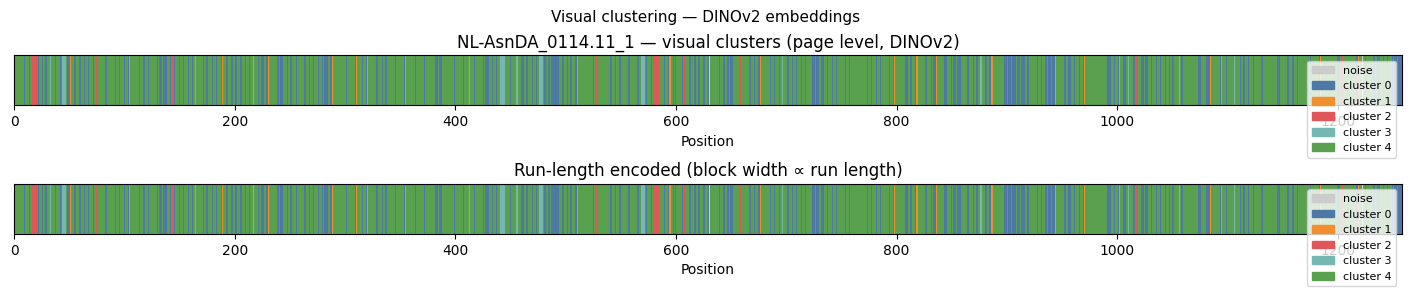


483 runs  (range 1–20 pages)


In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 2.8), constrained_layout=True)
plot_label_sequence(
    vis_labels_asda,
    title='NL-AsnDA_0114.11_1 — visual clusters (page level, DINOv2)',
    ax=axes[0],
)
rle_vis_asda = run_length_encode(vis_labels_asda)
plot_rle_sequence(rle_vis_asda, title='Run-length encoded (block width ∝ run length)', ax=axes[1])
plt.suptitle('Visual clustering — DINOv2 embeddings', fontsize=11)
plt.show()

print(f'\n{len(rle_vis_asda)} runs  '
      f'(range {min(r["length"] for r in rle_vis_asda)}–{max(r["length"] for r in rle_vis_asda)} pages)')

In [22]:
# Tandem repeats: look for the (text, blank) repeating deed unit
tr_vis_asda = find_tandem_repeats(vis_labels_asda, min_unit=1, max_unit=4, min_repeats=3)
print(f'Tandem repeats in AsnDA visual sequence ({len(tr_vis_asda)} total):')
if len(tr_vis_asda):
    print(tr_vis_asda[['unit', 'unit_length', 'start', 'n_repeats', 'total_length']]
          .head(15).to_string(index=False))

print()
ngrams_vis_asda = find_frequent_ngrams(vis_labels_asda, n=(2, 3), min_count=10)
print('Top n-grams in AsnDA visual sequence:')
print(ngrams_vis_asda[['ngram', 'n', 'count']].head(10).to_string(index=False))

Tandem repeats in AsnDA visual sequence (286 total):
        unit  unit_length  start  n_repeats  total_length
        (4,)            1      0          9             9
      (4, 4)            2      0          4             8
   (4, 4, 4)            3      0          3             9
        (4,)            1     10          3             3
        (2,)            1     15          6             6
      (2, 2)            2     15          3             6
        (4,)            1     22          3             3
        (4,)            1     33          4             4
        (4,)            1     38          3             3
        (3,)            1     43          4             4
        (4,)            1     51          3             3
(0, 4, 4, 4)            4     55          4            16
        (4,)            1     56          3             3
        (4,)            1     60          3             3
        (4,)            1     64          3             3

Top n-grams in Asn

In [23]:
tm_vis_asda = label_transition_matrix(vis_labels_asda, normalize=True)
print('Transition probabilities — AsnDA visual clustering:')
print(tm_vis_asda.round(2).to_string())

Transition probabilities — AsnDA visual clustering:
      0     1     2     3     4
0  0.37  0.07  0.00  0.00  0.56
1  0.00  0.00  0.00  0.00  1.00
2  0.07  0.00  0.61  0.00  0.32
3  0.00  0.00  0.00  0.52  0.48
4  0.24  0.00  0.01  0.01  0.73


## Summary

**NL-HaNA_2.10.50_1** — visual and layout clustering:
* Visual (DINOv2): cluster 2 scans (title pages / section separators) appear as single-scan
  punctuations at regular intervals within a dominant cluster-0 run (the table pages).
  The transition matrix shows cluster 2 transitions almost exclusively to/from cluster 0,
  confirming its role as a section marker.
* Layout: produces the same structural picture but with 80 % noise — the dense uniform
  table layout is hard to differentiate by text-line geometry alone.  Both approaches agree
  on the 11 section-separator positions.

**NL-AsnDA_0114.11_1** — layout clustering (Part 3) and visual clustering (Part 4):
* Layout (with empty pages): empty pages (`EMPTY_LABEL = -2`, 289 pages / 23 %) are kept
  as a structural signal.  The dominant n-gram is `(cluster 3, -2)` — full-text deed page
  followed by blank recto — and the transition matrix reveals the `3 → -2 → 3` rhythm.
  Tandem repeats of this pair encode the repeating deed unit throughout the sequence.
* Visual (DINOv2): with `min_cluster_size=20`, HDBSCAN produces 5 clusters.
  **Cluster 0 (325 pages, ~26 %)** captures 288 of the 289 layout-identified empty pages —
  the blank-recto convention emerges from visual appearance alone, without any
  `EMPTY_LABEL` flag.  The n-grams `(4, 0)` (text → blank, 203 occurrences) and
  `(0, 4)` (blank → text, 181 occurrences) confirm the same alternating deed-unit
  structure found by layout clustering.  The transition matrix shows cluster 4
  (the dominant text cluster, 854 pages) self-transitioning at 73 % and transitioning
  to cluster 0 at 24 % — exactly mirroring `3 → -2` in the layout sequence.